## 1.import des bibliotheques

In [127]:
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers
import pandas as pd
import matplotlib.pyplot as plt
import folium
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, cohen_kappa_score, confusion_matrix, ConfusionMatrixDisplay, classification_report
import matplotlib.patches as mpatches
from sklearn.utils.class_weight import compute_class_weight

## 2.charger les datasets

In [100]:
df_a = pd.read_csv("../Partie 1/Arkansas/Arkansas_full_clean.csv")

## 3. eda


In [101]:
df_a.info()
df_a.head()

<class 'pandas.DataFrame'>
RangeIndex: 9981 entries, 0 to 9980
Columns: 364 entries, B11_T0 to crop_name
dtypes: float64(362), int64(1), str(1)
memory usage: 27.7 MB


,B11_T0,B11_T1,B11_T10,B11_T11,B11_T12,B11_T13,B11_T14,B11_T15,B11_T16,B11_T17,...,B8_T4,B8_T5,B8_T6,B8_T7,B8_T8,B8_T9,crop_label,latitude,longitude,crop_name
0,3181.0,4241.0,5396.0,3931.0,4168.0,5218.0,0.0,0.0,3420.0,3276.0,...,0.0,5988.0,3051.0,3816.0,3416.0,3095.0,1,35.121630,-91.152407,Corn
1,3030.5,3529.5,5096.5,0.0,4901.5,4917.5,0.0,0.0,2766.0,2644.0,...,0.0,8876.5,3010.0,0.0,3217.0,3449.0,1,34.193840,-91.904585,Corn
2,3493.0,3742.0,4504.0,3782.0,4722.5,5072.0,5876.0,0.0,2652.0,2408.0,...,0.0,3533.0,2909.0,3913.0,3854.0,3244.0,1,34.581495,-91.237711,Corn
3,3344.5,4226.0,4617.0,3485.0,3645.0,0.0,3964.0,0.0,3116.5,2631.0,...,11080.0,0.0,2384.0,3112.0,0.0,3112.0,1,35.784738,-90.274934,Corn
4,3232.0,3589.0,5048.0,3738.0,4531.5,4309.0,2739.5,0.0,2602.5,2758.0,...,10928.0,3100.0,2771.0,3496.0,3298.0,2708.0,1,34.205083,-91.286998,Corn


In [102]:
df_a['crop_name'].value_counts()

crop_name
Soybeans    4680
Rice        2341
Corn        1501
Cotton       794
Others       665
Name: count, dtype: int64

In [103]:
df_a['crop_label'].value_counts()

crop_label
5      4680
3      2341
1      1501
2       794
176     553
61       51
121      24
190      12
122       7
141       5
123       4
37        4
10        2
143       1
26        1
152       1
Name: count, dtype: int64

## 4. data preprocessing

In [104]:
#ordonner les colonnes
nouvel_ordre = [
    'B2_T0','B3_T0','B4_T0','B5_T0','B6_T0','B7_T0','B8_T0','B8A_T0','B11_T0','B12_T0',
    'B2_T1','B3_T1','B4_T1','B5_T1','B6_T1','B7_T1','B8_T1','B8A_T1','B11_T1','B12_T1',
    'B2_T2','B3_T2','B4_T2','B5_T2','B6_T2','B7_T2','B8_T2','B8A_T2','B11_T2','B12_T2',
    'B2_T3','B3_T3','B4_T3','B5_T3','B6_T3','B7_T3','B8_T3','B8A_T3','B11_T3','B12_T3',
    'B2_T4','B3_T4','B4_T4','B5_T4','B6_T4','B7_T4','B8_T4','B8A_T4','B11_T4','B12_T4',
    'B2_T5','B3_T5','B4_T5','B5_T5','B6_T5','B7_T5','B8_T5','B8A_T5','B11_T5','B12_T5',
    'B2_T6','B3_T6','B4_T6','B5_T6','B6_T6','B7_T6','B8_T6','B8A_T6','B11_T6','B12_T6',
    'B2_T7','B3_T7','B4_T7','B5_T7','B6_T7','B7_T7','B8_T7','B8A_T7','B11_T7','B12_T7',
    'B2_T8','B3_T8','B4_T8','B5_T8','B6_T8','B7_T8','B8_T8','B8A_T8','B11_T8','B12_T8',
    'B2_T9','B3_T9','B4_T9','B5_T9','B6_T9','B7_T9','B8_T9','B8A_T9','B11_T9','B12_T9',
    'B2_T10','B3_T10','B4_T10','B5_T10','B6_T10','B7_T10','B8_T10','B8A_T10','B11_T10','B12_T10',
    'B2_T11','B3_T11','B4_T11','B5_T11','B6_T11','B7_T11','B8_T11','B8A_T11','B11_T11','B12_T11',
    'B2_T12','B3_T12','B4_T12','B5_T12','B6_T12','B7_T12','B8_T12','B8A_T12','B11_T12','B12_T12',
    'B2_T13','B3_T13','B4_T13','B5_T13','B6_T13','B7_T13','B8_T13','B8A_T13','B11_T13','B12_T13',
    'B2_T14','B3_T14','B4_T14','B5_T14','B6_T14','B7_T14','B8_T14','B8A_T14','B11_T14','B12_T14',
    'B2_T15','B3_T15','B4_T15','B5_T15','B6_T15','B7_T15','B8_T15','B8A_T15','B11_T15','B12_T15',
    'B2_T16','B3_T16','B4_T16','B5_T16','B6_T16','B7_T16','B8_T16','B8A_T16','B11_T16','B12_T16',
    'B2_T17','B3_T17','B4_T17','B5_T17','B6_T17','B7_T17','B8_T17','B8A_T17','B11_T17','B12_T17',
    'B2_T18','B3_T18','B4_T18','B5_T18','B6_T18','B7_T18','B8_T18','B8A_T18','B11_T18','B12_T18',
    'B2_T19','B3_T19','B4_T19','B5_T19','B6_T19','B7_T19','B8_T19','B8A_T19','B11_T19','B12_T19',
    'B2_T20','B3_T20','B4_T20','B5_T20','B6_T20','B7_T20','B8_T20','B8A_T20','B11_T20','B12_T20',
    'B2_T21','B3_T21','B4_T21','B5_T21','B6_T21','B7_T21','B8_T21','B8A_T21','B11_T21','B12_T21',
    'B2_T22','B3_T22','B4_T22','B5_T22','B6_T22','B7_T22','B8_T22','B8A_T22','B11_T22','B12_T22',
    'B2_T23','B3_T23','B4_T23','B5_T23','B6_T23','B7_T23','B8_T23','B8A_T23','B11_T23','B12_T23',
    'B2_T24','B3_T24','B4_T24','B5_T24','B6_T24','B7_T24','B8_T24','B8A_T24','B11_T24','B12_T24',
    'B2_T25','B3_T25','B4_T25','B5_T25','B6_T25','B7_T25','B8_T25','B8A_T25','B11_T25','B12_T25',
    'B2_T26','B3_T26','B4_T26','B5_T26','B6_T26','B7_T26','B8_T26','B8A_T26','B11_T26','B12_T26',
    'B2_T27','B3_T27','B4_T27','B5_T27','B6_T27','B7_T27','B8_T27','B8A_T27','B11_T27','B12_T27',
    'B2_T28','B3_T28','B4_T28','B5_T28','B6_T28','B7_T28','B8_T28','B8A_T28','B11_T28','B12_T28',
    'B2_T29','B3_T29','B4_T29','B5_T29','B6_T29','B7_T29','B8_T29','B8A_T29','B11_T29','B12_T29',
    'B2_T30','B3_T30','B4_T30','B5_T30','B6_T30','B7_T30','B8_T30','B8A_T30','B11_T30','B12_T30',
    'B2_T31','B3_T31','B4_T31','B5_T31','B6_T31','B7_T31','B8_T31','B8A_T31','B11_T31','B12_T31',
    'B2_T32','B3_T32','B4_T32','B5_T32','B6_T32','B7_T32','B8_T32','B8A_T32','B11_T32','B12_T32',
    'B2_T33','B3_T33','B4_T33','B5_T33','B6_T33','B7_T33','B8_T33','B8A_T33','B11_T33','B12_T33',
    'B2_T34','B3_T34','B4_T34','B5_T34','B6_T34','B7_T34','B8_T34','B8A_T34','B11_T34','B12_T34',
    'B2_T35','B3_T35','B4_T35','B5_T35','B6_T35','B7_T35','B8_T35','B8A_T35','B11_T35','B12_T35',
    'crop_label','latitude','longitude','crop_name'
]
df_a=df_a[nouvel_ordre]


In [105]:
df_a.head()

,B2_T0,B3_T0,B4_T0,B5_T0,B6_T0,B7_T0,B8_T0,B8A_T0,B11_T0,B12_T0,...,B6_T35,B7_T35,B8_T35,B8A_T35,B11_T35,B12_T35,crop_label,latitude,longitude,crop_name
0,1948.0,1971.0,2066.0,2391.0,2699.0,2850.0,2992.0,3107.0,3181.0,2356.0,...,2583.0,2749.0,2914.0,3005.0,3873.0,3208.0,1,35.121630,-91.152407,Corn
1,1327.0,1543.0,1674.0,2222.5,2948.5,3173.0,3413.5,3450.0,3030.5,2250.5,...,0.0,0.0,0.0,0.0,0.0,0.0,1,34.193840,-91.904585,Corn
2,1578.0,1900.0,2305.0,2684.0,2891.0,3028.0,3138.0,3226.0,3493.0,2851.0,...,3395.0,3637.0,3648.0,3763.0,3708.0,3046.0,1,34.581495,-91.237711,Corn
3,1592.0,1723.0,1890.0,2112.0,2232.0,2337.5,2579.0,2557.5,3344.5,2666.0,...,2730.0,2846.0,3177.0,3101.5,2680.0,2024.0,1,35.784738,-90.274934,Corn
4,1561.0,1870.0,1932.0,2632.5,3458.0,3638.5,3844.0,3850.0,3232.0,2393.0,...,2671.0,2793.0,2970.0,2998.0,3206.0,2498.0,1,34.205083,-91.286998,Corn


In [106]:
#separer x et y
df_a_x = df_a.drop(columns=['crop_label','latitude','longitude','crop_name'])
X_a = df_a_x.values
df_a_y =df_a[['crop_name','crop_label']]
df_a_y.loc[df_a['crop_name'] == 'Others', 'crop_label'] = 0
df_a_y.loc[df_a['crop_label'] == 5, 'crop_label'] = 4
y_a = df_a_y['crop_label'].values

In [107]:
#reshape
X_a = X_a.reshape(-1,36,10)  



In [108]:
mask_a = (X_a != 0).astype(float)

In [ ]:

def split_par_classe(df, X, y, mask, n_per_class=300, val_ratio=0.2, random_state=42):

    train_idx = []
    val_idx   = []
    test_idx  = []

    for classe in np.unique(y):
        idx_classe = np.where(y == classe)[0]

        # Séparer les 300 échantillons du reste (test)
        idx_trainval, idx_test = train_test_split(
            idx_classe,
            train_size=n_per_class,   # exactement 300 par classe
            random_state=random_state,
            shuffle=True
        )

        # Parmi les 300 → 240 train / 60 val (ratio 0.2)
        idx_train, idx_val = train_test_split(
            idx_trainval,
            test_size=val_ratio,      # 20% de 300 = 60 val
            random_state=random_state,
            shuffle=True
        )

        train_idx.extend(idx_train)
        val_idx.extend(idx_val)
        test_idx.extend(idx_test)

    # Convertir en arrays
    train_idx = np.array(train_idx)
    val_idx   = np.array(val_idx)
    test_idx  = np.array(test_idx)

    return (
        X[train_idx], X[val_idx],   X[test_idx],
        y[train_idx], y[val_idx],   y[test_idx],
        mask[train_idx], mask[val_idx], mask[test_idx]
    )


(X_a_train, X_a_val, X_a_test,
 y_a_train, y_a_val, y_a_test,
 mask_a_train, mask_a_val, mask_a_test) = split_par_classe(
    df_a, X_a, y_a,
    mask=mask_a,
    n_per_class=300,
    val_ratio=0.2,
    random_state=42
)

#normalisation
X_max = X_a_train.max(axis=(0, 1), keepdims=True)
X_max[X_max == 0] = 1

X_a_train = X_a_train / X_max
X_a_val   = X_a_val   / X_max  
X_a_test  = X_a_test  / X_max  

print(X_a_train.shape)  
print(mask_a_train.shape)

(1200, 36, 10)
(1200, 36, 10)


## 5. le modele

In [110]:

#Le CNN
def CNNBlock(x):
    shortcut = x
    dim = x.shape[-1]

    x = layers.Conv1D(filters=dim, kernel_size=3, padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)

    x = layers.Conv1D(filters=dim, kernel_size=3, padding='same')(x)
    x = layers.BatchNormalization()(x)

    x = layers.Add()([x, shortcut])  # shortcut connection
    x = layers.ReLU()(x)
    return x

In [111]:
#Transformer
def TransformerBlock(x, num_heads=5):
    dim = x.shape[-1]

    # Multi-head attention
    attn = layers.MultiHeadAttention(num_heads=num_heads, key_dim=dim)(x, x)
    x = layers.Add()([x, attn])
    x = layers.LayerNormalization()(x)

    # Feed Forward
    ff  = layers.Dense(dim * 4, activation='gelu')(x)  # gelu > relu 
    ff = layers.Dense(dim)(ff)

    x = layers.Add()([x, ff])
    x = layers.LayerNormalization()(x)

    return x

In [112]:



def get_sinusoidal_PE(T=36, d_model=10):
    pe = np.zeros((T, d_model))
    for t in range(T):
        for i in range(0, d_model, 2):
            pe[t, i]     = np.sin(t / (10000 ** (2*i / d_model)))
            if i+1 < d_model:
                pe[t, i+1] = np.cos(t / (10000 ** (2*i / d_model)))
    return tf.constant(pe[np.newaxis, :, :], dtype=tf.float32)  # (1, 36, 10)

PE_MATRIX = get_sinusoidal_PE(T=36, d_model=10) * 0.1  # ← scale important

def ALPE(x, mask):
    # ① PE ajoutée EN PREMIER, avant le masque
    x_with_pe = x + PE_MATRIX

    # ② Masque appliqué APRÈS
    x_masked = layers.Multiply()([x_with_pe, mask])

    # ③ Conv1D (inchangé)
    C = x.shape[-1]
    x_conv = layers.Conv1D(filters=C, kernel_size=3, padding='same')(x_masked)

    # ④ ECA (inchangé)
    import math
    t_val = int(math.log2(C) / 2 + 1 / 2)
    k = t_val if t_val % 2 else t_val + 1

    w = layers.GlobalAveragePooling1D()(x_conv)
    w = layers.Reshape((C, 1))(w)
    w = layers.Conv1D(filters=1, kernel_size=k, padding='same', use_bias=False)(w)
    w = layers.Activation('sigmoid')(w)
    w = layers.Reshape((1, C))(w)

    return layers.Multiply()([x_conv, w])

In [113]:
def CTFusion(x):
    cnn_out = CNNBlock(x)
    trans_out = TransformerBlock(x)
    fused = layers.Concatenate()([cnn_out, trans_out]) 
    fused = layers.Dense(x.shape[-1])(fused)   
    fused = layers.Dropout(0.2)(fused)       
    return fused

In [114]:
def build_MCTNet_LSTM(input_shape=(36, 10), num_classes=5):
    inputs = tf.keras.Input(shape=input_shape)
    mask = tf.keras.Input(shape=input_shape)

    x = ALPE(inputs, mask)

    x = CTFusion(x)
    x = layers.MaxPooling1D(pool_size=2)(x)

    x = CTFusion(x)
    x = layers.MaxPooling1D(pool_size=2)(x)

    x = CTFusion(x)


    x = layers.Bidirectional(layers.LSTM(128, return_sequences=False))(x)
    x = layers.Dropout(0.3)(x)

    x = layers.Dense(64, activation='relu')(x)
   
    outputs = layers.Dense(num_classes, activation='softmax')(x)
    x = layers.Dropout(0.2)(x)
    model = tf.keras.Model(inputs=[inputs, mask], outputs=outputs)

    return model

In [115]:
model = build_MCTNet_LSTM()



model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001,clipnorm=1.0),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "functional_16"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_34      │ (None, 36, 10)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_170 (Add)       │ (None, 36, 10)    │          0 │ input_layer_34[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_35      │ (None, 36, 10)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply_34         │ (None, 36, 10)    │          0 │ add_170[0][0],    │
│ (Multiply)          │                   │            │ input_layer_35[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_136 (Conv1D) │ (None, 36, 10)    │        310 │ multiply_34[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 10)        │          0 │ conv1d_136[0][0]  │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape_34          │ (None, 10, 1)     │          0 │ global_average_p… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_137 (Conv1D) │ (None, 10, 1)     │          3 │ reshape_34[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_17       │ (None, 10, 1)     │          0 │ conv1d_137[0][0]  │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape_35          │ (None, 1, 10)     │          0 │ activation_17[0]… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply_35         │ (None, 36, 10)    │          0 │ conv1d_136[0][0], │
│ (Multiply)          │                   │            │ reshape_35[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_138 (Conv1D) │ (None, 36, 10)    │        310 │ multiply_35[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 36, 10)    │      2,160 │ multiply_35[0][0… │
│ (MultiHeadAttentio… │                   │            │ multiply_35[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 36, 10)    │         40 │ conv1d_138[0][0]  │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_172 (Add)       │ (None, 36, 10)    │          0 │ multiply_35[0][0… │
│                     │                   │            │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_102 (ReLU)    │ (None, 36, 10)    │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 36, 10)    │         20 │ add_172[0][0]     │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_139 (Conv1D) │ (None, 36, 10)    │        310 │ re_lu_102[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_186 (Dense)   │ (None, 36, 40)    │        440 │ layer_normalizat

 Total params: 171,302 (669.15 KB)

 Trainable params: 171,182 (668.68 KB)

 Non-trainable params: 120 (480.00 B)

In [128]:
callbacks = [
    
    tf.keras.callbacks.EarlyStopping(
    monitor='val_accuracy',      
    patience=20,
    min_delta=0.001,
    restore_best_weights=True
),
    tf.keras.callbacks.ModelCheckpoint(
        'best_model.keras', 
        monitor='val_accuracy', 
        save_best_only=True
    )
]

cw = compute_class_weight('balanced', classes=np.unique(y_a_train), y=y_a_train)
class_weight = dict(enumerate(cw))
class_weight[0] = class_weight[0] * 0.3
print(class_weight)

history=model.fit(
    [X_a_train, mask_a_train],
    y_a_train,
    validation_data=([X_a_val, mask_a_val], y_a_val),
    epochs=100,
    batch_size=64,
    callbacks=callbacks,
    class_weight=class_weight
)

{0: np.float64(0.3), 1: np.float64(1.0), 2: np.float64(1.0), 3: np.float64(1.0), 4: np.float64(1.0)}
Epoch 1/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 6s 334ms/step - accuracy: 0.9792 - loss: 0.0445 - val_accuracy: 0.8833 - val_loss: 0.4853
Epoch 2/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 6s 318ms/step - accuracy: 0.9767 - loss: 0.0447 - val_accuracy: 0.9567 - val_loss: 0.2955
Epoch 3/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 4s 235ms/step - accuracy: 0.9808 - loss: 0.0462 - val_accuracy: 0.8333 - val_loss: 0.8548
Epoch 4/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 5s 239ms/step - accuracy: 0.9767 - loss: 0.0588 - val_accuracy: 0.9333 - val_loss: 0.3691
Epoch 5/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 5s 275ms/step - accuracy: 0.9817 - loss: 0.0394 - val_accuracy: 0.9300 - val_loss: 0.4167
Epoch 6/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 5s 261ms/step - accuracy: 0.9833 - loss: 0.0287 - val_accuracy: 0.9533 - val_loss: 0.3007
Epoch 7/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 6s 312ms/step - accuracy: 0.9783 - loss: 0.0446 - val_accuracy: 0.9600 - val_loss: 0.2

In [130]:

y_a_pred = model.predict([X_a_test, mask_a_test])
y_a_pred = y_a_pred.argmax(axis=1)

oa = accuracy_score(y_a_test, y_a_pred)
f1 = f1_score(y_a_test, y_a_pred, average='macro')
kappa = cohen_kappa_score(y_a_test, y_a_pred)

print("OA:", oa)
print("F1:", f1)
print("Kappa:", kappa)



266/266 ━━━━━━━━━━━━━━━━━━━━ 15s 57ms/step
OA: 0.9434029006013441
F1: 0.9051848380659562
Kappa: 0.9150082646512293


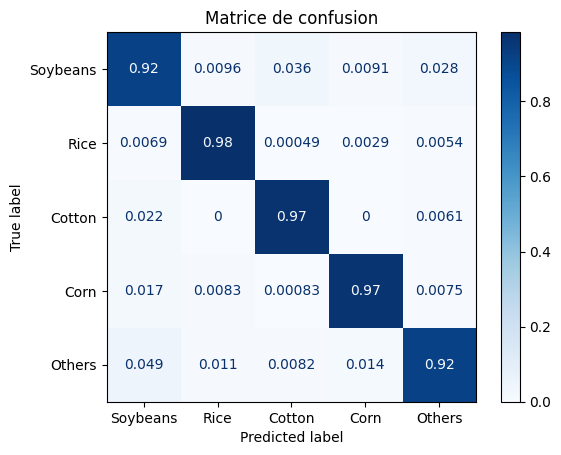


Classification Report :

              precision    recall  f1-score   support

           0       0.70      0.92      0.79       365
           1       0.96      0.97      0.96      1201
           2       0.75      0.97      0.84       494
           3       0.97      0.98      0.98      2041
           4       0.98      0.92      0.95      4380

    accuracy                           0.94      8481
   macro avg       0.87      0.95      0.91      8481
weighted avg       0.95      0.94      0.95      8481



In [131]:
# Confusion Matrix 
labels = ["Soybeans", "Rice", "Cotton", "Corn", "Others"]
cm = confusion_matrix(y_a_test, y_a_pred,labels=[4,3,2,1,0])
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_norm,display_labels=labels)
disp.plot(cmap="Blues")
plt.title("Matrice de confusion")
plt.show()

print("\nClassification Report :\n")
print(classification_report(y_a_test, y_a_pred))

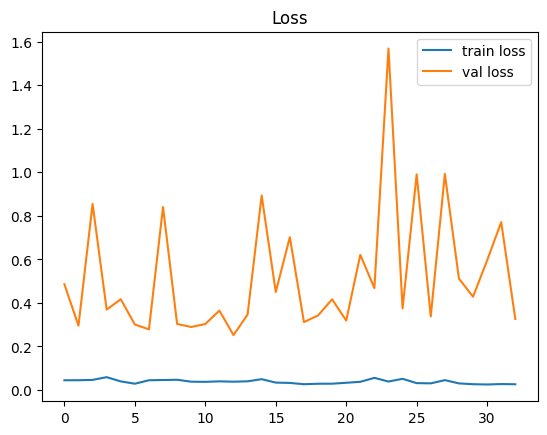

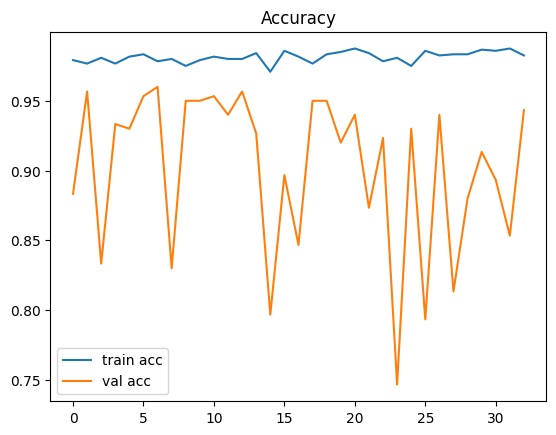

In [132]:
# Learning plots
plt.plot(history.history["loss"], label="train loss")
plt.plot(history.history["val_loss"], label="val loss")
plt.legend()
plt.title("Loss")
plt.show()

plt.plot(history.history["accuracy"], label="train acc")
plt.plot(history.history["val_accuracy"], label="val acc")
plt.legend()
plt.title("Accuracy")
plt.show()